# Student Info
### Chinese Name: Li Anran
### English Name: Yuki
### ID:C00292764

## Introduction

This dataset contains detailed geometric measurements of banknotes, recording the physical characteristics of 1,500 bills (1,000 genuine and 500 counterfeit), suitable for authenticity identification research.

I selected this dataset because it presents a well-structured binary classification problem, suitable for applying and comparing various machine learning algorithms. For example, the K-Nearest Neighbors (KNN) classifier can be used to determine authenticity based on geometric features, and other classification models (such as K-Medoids, etc.) can also be tested to compare their performance on this task. The target variable is is_genuine (whether the bill is genuine or not).

This classification problem has practical application value—by using geometric features such as diagonal length, left and right height, margins, and overall length, a model can be built to predict the authenticity of banknotes. Additionally, this dataset is also suitable for practicing preprocessing methods such as feature standardization and dimensionality reduction (e.g., Principal Component Analysis, PCA).

In [126]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/fake-bills/fake_bills.csv


## loading and exploring data

* is_genuine(boolean): Whether the bill is genuine or fake(True = Genuine, False = Fake)
* diagonal(float): Diagonal measurement of the bill(mm)
* height_left(float): Height of the left side of the bill (mm)
* height_right(float): Height of the right side of the bill (mm)
* margin_low(float): Lower margin of the bill (mm)
* margin_upper(float): Upper margin of the bill (mm)
* length(float): Length of the bill (mm)

In [127]:
df = pd.read_csv("/kaggle/input/fake-bills/fake_bills.csv", sep=';')
df.head(10)

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
5,True,172.17,103.74,104.08,4.42,2.95,112.81
6,True,172.34,104.18,103.85,4.58,3.26,112.81
7,True,171.88,103.76,104.08,3.98,2.92,113.08
8,True,172.47,103.92,103.67,4.00,3.25,112.85
9,True,172.47,104.07,104.02,4.04,3.25,113.45


Descriptive statistics reveal significant scale differences across geometric features: length operates on a much larger numeric range compared to margin measurements. Such varying scales across features can distort distance calculations, justifying the application of feature scaling to improve the performance and stability of the KNN classifier. The low variance and concentrated distributions remain beneficial for distance-based modeling and classification boundary learning after scaling.

In [128]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Margin_low: 37 missing values

In [129]:
print(df.isnull().sum())
print(df.dtypes)

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object


## Handling Missing Data

Using mean imputation to fill missing values in the margin_low feature.

In [130]:
mean = df['margin_low'].mean()
df['margin_low'] = df['margin_low'].fillna(mean)

print(df['margin_low'].isnull().sum())

0


## Scale

Histogram visualization shows that all six numerical features approximately follow normal distributions with highly concentrated values. However, there are noticeable scale differences between features: 

diagonal length ranges between 171.5–172.5 mm, left/right heights fall within 103.5–104.5 mm, upper margin (margin_up) lies between 2.5–3.5 mm, lower margin (margin_low) is between 4.0–5.0 mm, while length is concentrated in 112–114 mm. 

Such scale variation—especially the order-of-magnitude difference between length and margin features—can adversely affect distance-based KNN performance. Therefore, feature standardization is required in subsequent steps to eliminate scale effects and ensure equal contribution from each feature during modeling.

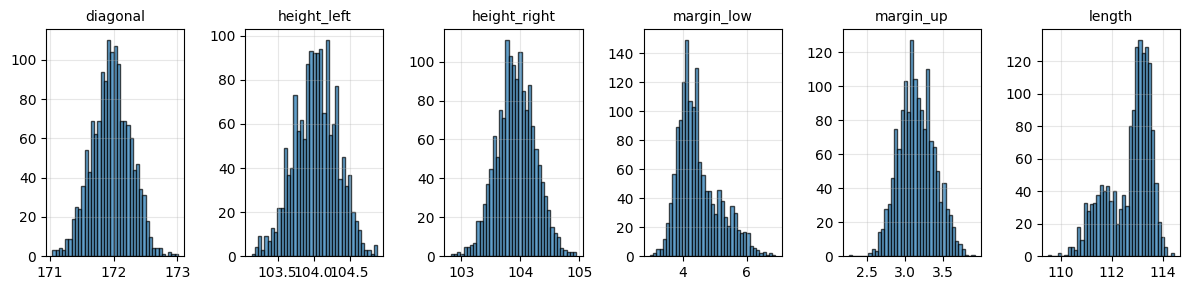

In [131]:
import matplotlib.pyplot as plt

numeric_cols = [col for col in df.columns if col != 'is_genuine']

plt.figure(figsize=(12, 3))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    plt.hist(df[col], bins="sqrt", edgecolor='black', alpha=0.7)
    plt.title(col, fontsize=10)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Standardizing numerical features using StandardScaler to eliminate scale differences that could distort KNN distance calculations

In [132]:
from sklearn.preprocessing import StandardScaler

features = df.drop('is_genuine', axis=1)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

## Reduce dimension

First, a correlation matrix was computed to identify linear relationships between features and their associations with the target variable. The results indicate that several features show significant correlations with is_genuine: length exhibits a strong positive correlation, while margin_low and margin_up show strong negative correlations. These correlations suggest that some features may share overlapping information, providing a basis for subsequent dimensionality reduction.

In [133]:
corr_matrix = df.corr(numeric_only=True)
display(corr_matrix.round(2).style.background_gradient(cmap='viridis'))

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,1.000000,0.130000,-0.380000,-0.490000,-0.780000,-0.610000,0.850000
diagonal,0.130000,1.000000,0.020000,-0.020000,-0.110000,-0.060000,0.100000
height_left,-0.380000,0.020000,1.000000,0.240000,0.300000,0.250000,-0.320000
height_right,-0.490000,-0.020000,0.240000,1.000000,0.380000,0.310000,-0.400000
margin_low,-0.780000,-0.110000,0.300000,0.380000,1.000000,0.430000,-0.660000
margin_up,-0.610000,-0.060000,0.250000,0.310000,0.430000,1.000000,-0.520000
length,0.850000,0.100000,-0.320000,-0.400000,-0.660000,-0.520000,1.000000


Based on the correlation analysis, Principal Component Analysis (PCA) was applied to the standardized features with a variance retention threshold of 90%. After dimensionality reduction, the number of features decreased from the original 6 to 5 principal components. This process retains the majority of the original data information while effectively reducing multicollinearity among features and improving the computational efficiency and stability of the subsequent KNN model.

In [134]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"from {df.shape[1]-1} features reduce to {X_pca.shape[1]} features")

from 6 features reduce to 5 features


## Split data

In [135]:
from sklearn.model_selection import train_test_split

X = df.drop('is_genuine', axis=1)
y = df['is_genuine']
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

## Modeling

### KNN

Using 10-fold cross-validation to evaluate performance for different K values, the results show that n_neighbors=2 achieves the highest accuracy. As K increases, model performance shows a slight downward trend.

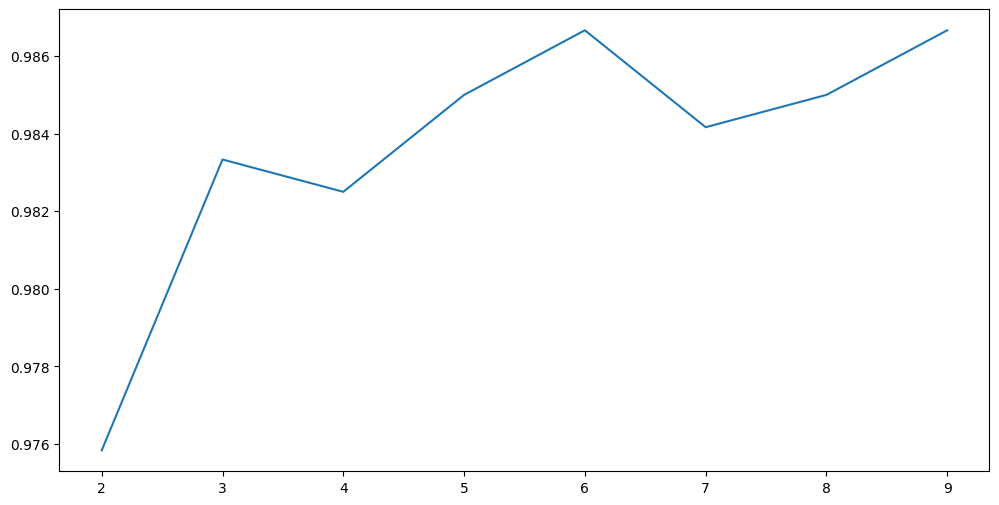

In [136]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import seaborn as sns

neighbors = [2,3,4,5,6,7,8,9]
scores = []


for n in neighbors:
    model = KNeighborsClassifier(n_neighbors=n)
    acc = cross_val_score(model, X_train, y_train, cv=10, n_jobs=-1)
    
    scores.append(np.mean(acc))
    
plt.figure(figsize=(12,6))
sns.lineplot(x=neighbors, y=scores);

A KNN classifier with K=6 was constructed, achieving 99% accuracy on the test set. For counterfeit detection, precision is 1.00 with recall of 0.96. For genuine detection, precision is 0.98 with recall of 1.00. The model demonstrates balanced performance across both classes and shows strong generalization capability.

In [137]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

knn = KNeighborsClassifier(n_neighbors=6, weights='uniform', metric='euclidean')

knn.fit(X_train, y_train)

for (i, x, y) in zip(["Train", "Test"], [X_train, X_test], [y_train, y_test]):
    print(f"\nClassification kNN {i} report:")
    print(classification_report(y, knn.predict(x), digits=3))


Classification kNN Train report:
              precision    recall  f1-score   support

       False      0.990     0.977     0.983       390
        True      0.989     0.995     0.992       810

    accuracy                          0.989      1200
   macro avg      0.989     0.986     0.988      1200
weighted avg      0.989     0.989     0.989      1200


Classification kNN Test report:
              precision    recall  f1-score   support

       False      1.000     0.982     0.991       110
        True      0.990     1.000     0.995       190

    accuracy                          0.993       300
   macro avg      0.995     0.991     0.993       300
weighted avg      0.993     0.993     0.993       300



### K-Medoids

K-Medoids is more resistant to outliers compared to K-Means and is suitable for small-scale datasets. By using actual data points (medoids) as cluster centers, it performs more stably on numerical features derived from categorical data, enabling better distinction between "genuine" and "fake" categories.

The following code is used to perform K-Medoids clustering on the standardized feature data and assign cluster labels.

The cross-tabulation results show that the cluster labels are highly consistent with the true labels "is_genuine", indicating that K-Medoids successfully identified the two categories, with only a few samples misclassified.

In [138]:
!pip install kmedoids
from kmedoids import KMedoids

Kmedoids = KMedoids(n_clusters=2, metric="euclidean",random_state=42)
df["cluster_label"] = Kmedoids.fit_predict(X_scaled)

print(pd.crosstab(df["is_genuine"], df["cluster_label"]))

cluster_label    0    1
is_genuine             
False           12  488
True           983   17


We map the cluster labels to match the true labels and then print a classification report to evaluate the model's performance.

The distribution patterns of the two scatter plots are similar, indicating that the clustering results largely match the actual classifications, validating the effectiveness of K-Medoids.

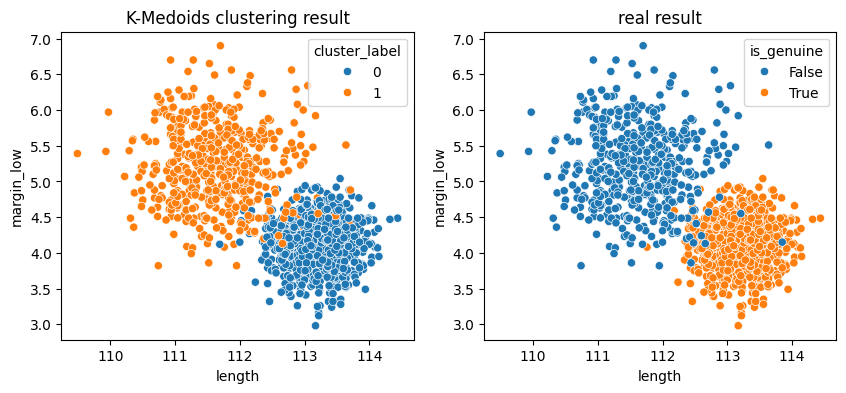

In [139]:
f, (a1,a2) = plt.subplots(1,2,figsize=(10,4))
sns.scatterplot(data=df, x="length", y="margin_low", hue="cluster_label", ax=a1)
sns.scatterplot(data=df, x="length", y="margin_low", hue="is_genuine", ax=a2)
a1.set_title("K-Medoids clustering result")
a2.set_title("real result")
plt.show()

The classification report shows accuracy, precision, and recall all above 0.98, indicating that the model performs excellently on both categories and effectively distinguishes genuine from fake samples.

In [140]:
df['cluster_label_mapped'] = df['cluster_label'].map({0: True, 1: False})

print("K-Medoids Classification Report:")
print(classification_report(df['is_genuine'], df['cluster_label_mapped'], digits=3))

K-Medoids Classification Report:
              precision    recall  f1-score   support

       False      0.966     0.976     0.971       500
        True      0.988     0.983     0.985      1000

    accuracy                          0.981      1500
   macro avg      0.977     0.980     0.978      1500
weighted avg      0.981     0.981     0.981      1500



## Conclusion

By comparing the performance of the K-Nearest Neighbors (KNN) algorithm and K-Medoids clustering, both methods achieved excellent results in distinguishing genuine from fake samples, with KNN slightly outperforming K-Medoids in accuracy.

In this study, I primarily addressed significant scale differences among features through data standardization, and mitigated information overlap between features via dimensionality reduction, laying a solid data foundation for subsequent modeling.